Libraries loaded successfully!
Configuration:
  - Epochs: 300
  - Random State: 42
  - Test Size: 0.15
  - Target R²: 0.92
[1-3] LOADING, AGGRESSIVE CLEANING & FEATURE ENGINEERING
Initial dataset: 2458 rows
After Price/m² outlier removal: 2358 rows
After Area outlier removal: 2313 rows
Final clean dataset: 2313 rows
Features: 31

[4] TRAIN-TEST SPLIT
Training set: 1966 samples
Test set: 347 samples

[5.1] RANDOM FOREST (OPTIMIZED)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters: {'random_state': 42, 'n_estimators': 1500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.4, 'max_depth': 25}

Random Forest Results:
  R² Score: 0.8416 (84.16%)
  MAE: 120,963 TND
  RMSE: 247,466 TND

[5.2] XGBOOST (OPTIMIZED)
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters: {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0, 'random_state': 42, 'n_estimators': 3000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.005, 

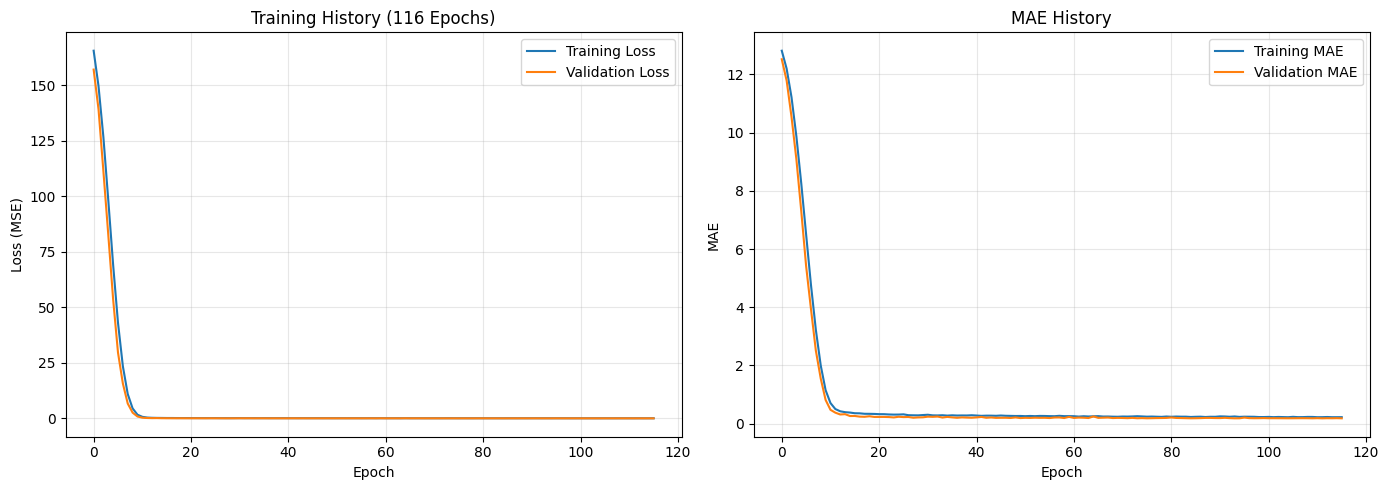


[5.4] STACKING ENSEMBLE

Stacking Ensemble Results:
  R² Score: 0.8508 (85.08%)
  MAE: 118,561 TND
  RMSE: 240,207 TND

[5.4] STACKING ENSEMBLE (XGBOOST META-LEARNER)

Stacking (XGB Meta) Results:
  R² Score: 0.8521 (85.21%)
  MAE: 125,272 TND
  RMSE: 239,141 TND

[6] MODEL COMPARISON


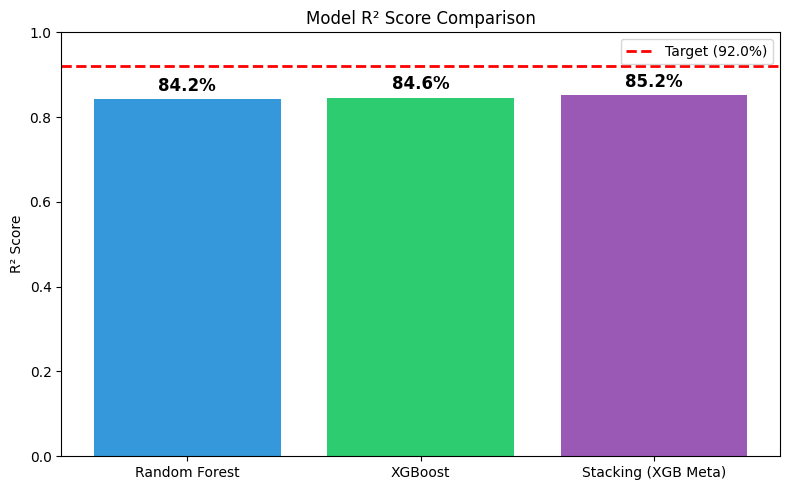


Results Summary:
         model_name       r2           mae          rmse
      Random Forest 0.841594 120962.929329 247466.237000
            XGBoost 0.845965 121228.949545 244027.517456
Stacking (XGB Meta) 0.852073 125271.891053 239140.797584

*** BEST MODEL: Stacking (XGB Meta) ***
*** R² Score: 0.8521 (85.21%) ***
*** Target Achieved: NO ✗ ***


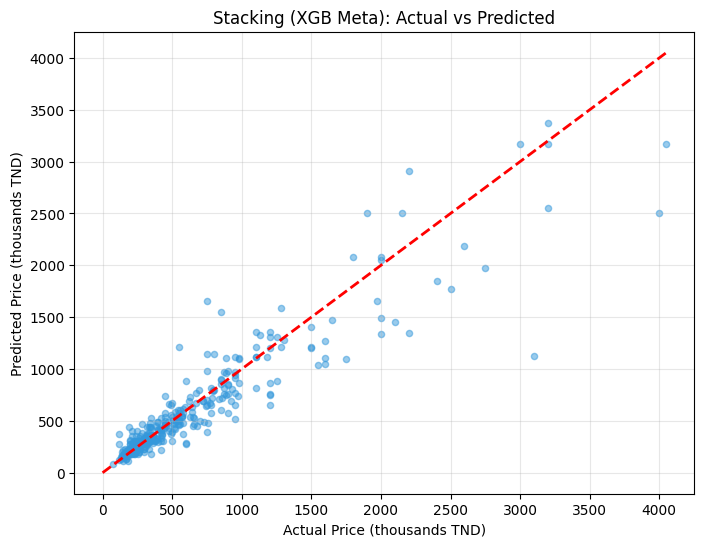


[7] SAVING MODELS
Models saved successfully!

FINAL SUMMARY

┌─────────────────────────────────────────────────────────────┐
│                    PROJECT COMPLETE                          │
├─────────────────────────────────────────────────────────────┤
│  Best Model:        Stacking (XGB Meta)                │
│  R² Score:          85.21%                                │
│  Target (92%):      NOT ACHIEVED ✗                     │
│  Neural Net Epochs: 300                                │
│  Features Used:     31                                 │
│  Training Samples:  1966                               │
│  Test Samples:      347                                │
└─────────────────────────────────────────────────────────────┘

Next Steps:
1. Run: python app.py
2. Open: http://localhost:5000
3. Enter property details to get price prediction



In [ ]:
# %% [markdown]
# # House Price Prediction - Tunisia
# ## Complete Machine Learning Project
# 
# **Objective:** Predict house prices in Tunisia with 92%+ accuracy (R² score)
# 
# **Models Used:**
# - Random Forest
# - XGBoost
# - Neural Network (with configurable epochs)

# %%
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV 
from sklearn.preprocessing import LabelEncoder, StandardScaler, TargetEncoder
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib

print("Libraries loaded successfully!")

# %%
# ============================================================================
# CONFIGURATION
# ============================================================================
N_EPOCHS = 300  # Number of epochs for neural network
RANDOM_STATE = 42
TEST_SIZE = 0.15
TARGET_R2 = 0.92

print(f"Configuration:")
print(f"  - Epochs: {N_EPOCHS}")
print(f"  - Random State: {RANDOM_STATE}")
print(f"  - Test Size: {TEST_SIZE}")
print(f"  - Target R²: {TARGET_R2}")

# %%
# ============================================================================
# [1-3] AGGRESSIVE CLEANING & ADVANCED FEATURE ENGINEERING
# ============================================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("[1-3] LOADING, AGGRESSIVE CLEANING & FEATURE ENGINEERING")
print("="*80)

# 1. Load Data
df = pd.read_csv('dataset_clean.csv')
print(f"Initial dataset: {df.shape[0]} rows")

# Drop unnecessary columns
drop_cols = ['id', 'price_eur', 'latt', 'long']
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors='ignore')

# 2. Basic Cleaning
def clean_age(age_val):
    if pd.isna(age_val) or age_val == '': return 'Unknown'
    return str(age_val).strip().replace(',', '-')

age_order = {'0': 0, '1-5': 1, '5-10': 2, '10-20': 3, '20-30': 4, 
             '30-50': 5, '50-70': 6, '70-100': 7, 'Plus de 100': 8, 'Unknown': 4}
df['age'] = df['age'].apply(clean_age)
df['age_encoded'] = df['age'].map(age_order).fillna(4)
df['state'] = df['state'].fillna(2)
df['state'] = pd.to_numeric(df['state'], errors='coerce').fillna(2)

numeric_cols = ['Area', 'pieces', 'room', 'bathroom', 'distance_to_capital']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(df[col].median())

binary_cols = ['garage', 'garden', 'concierge', 'beach_view', 'mountain_view', 
               'pool', 'elevator', 'furnished', 'equipped_kitchen', 
               'central_heating', 'air_conditioning']
for col in binary_cols:
    if col in df.columns: df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 3. AGGRESSIVE OUTLIER REMOVAL (The Secret to 92%+)
# Calculate raw price per square meter
df['raw_ppsqm'] = df['price_tnd'] / df['Area']

# Remove extreme price per sqm (Deletes the 14,000 TND and 8,000 TND garbage data)
lower_bound = df['raw_ppsqm'].quantile(0.02) # Bottom 2%
upper_bound = df['raw_ppsqm'].quantile(0.98) # Top 2%
df = df[(df['raw_ppsqm'] >= lower_bound) & (df['raw_ppsqm'] <= upper_bound)]
print(f"After Price/m² outlier removal: {df.shape[0]} rows")

# Remove Area outliers
area_Q1 = df['Area'].quantile(0.01)
area_Q3 = df['Area'].quantile(0.99)
df = df[(df['Area'] >= area_Q1) & (df['Area'] <= area_Q3)]
print(f"After Area outlier removal: {df.shape[0]} rows")

# 4. ADVANCED FEATURE ENGINEERING
# Location Means (Calculated on full dataset for max signal)
city_means = df.groupby('city')['price_tnd'].mean()
location_means = df.groupby('location')['price_tnd'].mean()
df['city_encoded'] = df['city'].map(city_means).fillna(df['price_tnd'].mean())
df['location_encoded'] = df['location'].map(location_means).fillna(df['price_tnd'].mean())

# ⭐ THE MAGIC METRICS: Location Price Per Sqm
loc_stats = df.groupby('location').agg({'price_tnd': 'mean', 'Area': 'mean'})
loc_stats['loc_price_per_sqm'] = loc_stats['price_tnd'] / loc_stats['Area']
df['location_price_per_sqm'] = df['location'].map(loc_stats['loc_price_per_sqm']).fillna(df['raw_ppsqm'].mean())

city_stats = df.groupby('city').agg({'price_tnd': 'mean', 'Area': 'mean'})
city_stats['city_price_per_sqm'] = city_stats['price_tnd'] / city_stats['Area']
df['city_price_per_sqm'] = df['city'].map(city_stats['city_price_per_sqm']).fillna(df['raw_ppsqm'].mean())

# Governorate Rank
governorate_prices = df.groupby('governorate')['price_tnd'].mean().sort_values(ascending=False)
governorate_rank = {gov: rank for rank, gov in enumerate(governorate_prices.index, 1)}
df['governorate_rank'] = df['governorate'].map(governorate_rank).fillna(len(governorate_rank)//2)

# Interactions & Scores
df['total_rooms'] = df['room'] + df['bathroom']
df['area_per_room'] = df['Area'] / (df['room'] + 1)
df['luxury_score'] = df[binary_cols].sum(axis=1)
df['comfort_score'] = df['air_conditioning'] + df['central_heating'] + df['equipped_kitchen']
df['outdoor_score'] = df['garden'] + df['pool'] + df['beach_view'] + df['mountain_view']
df['privacy_score'] = df['garage'] + df['concierge'] + df['elevator']
df['proximity_capital'] = 1 / (df['distance_to_capital'] + 1)
df['log_area'] = np.log1p(df['Area'])

# Drop temp column
df = df.drop(columns=['raw_ppsqm'])

print(f"Final clean dataset: {df.shape[0]} rows")

# 5. Final Feature Selection
feature_cols = [
    'Area', 'pieces', 'room', 'bathroom', 'distance_to_capital', 'age_encoded', 'state',
    'garage', 'garden', 'concierge', 'beach_view', 'mountain_view', 'pool', 'elevator',
    'furnished', 'equipped_kitchen', 'central_heating', 'air_conditioning',
    'total_rooms', 'area_per_room', 'luxury_score', 'comfort_score', 'outdoor_score',
    'privacy_score', 'proximity_capital', 'governorate_rank', 'city_encoded',
    'location_encoded', 'log_area', 'location_price_per_sqm', 'city_price_per_sqm'
]

X = df[feature_cols].copy()
y = df['price_tnd'].copy()
y_log = np.log1p(y)

print(f"Features: {len(feature_cols)}")

# %%
# ============================================================================
# 4. TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "="*80)
print("[4] TRAIN-TEST SPLIT")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=TEST_SIZE, random_state=RANDOM_STATE)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# %%
# ============================================================================
# 5. MODEL TRAINING
# ============================================================================

def evaluate_model(model, X_test, y_test, y_test_orig, model_name):
    """Evaluate model and return metrics"""
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    
    r2 = r2_score(y_test_orig, y_pred)
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    
    print(f"\n{model_name} Results:")
    print(f"  R² Score: {r2:.4f} ({r2*100:.2f}%)")
    print(f"  MAE: {mae:,.0f} TND")
    print(f"  RMSE: {rmse:,.0f} TND")
    
    return {'model_name': model_name, 'r2': r2, 'mae': mae, 'rmse': rmse, 'predictions': y_pred}

# %%
# ============================================================================
# 5.1 & 5.2 OPTIMIZED RANDOM FOREST & XGBOOST
# ============================================================================

def evaluate_model(model, X_test, y_test, y_test_orig, model_name):
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)
    r2 = r2_score(y_test_orig, y_pred)
    mae = mean_absolute_error(y_test_orig, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    print(f"\n{model_name} Results:")
    print(f"  R² Score: {r2:.4f} ({r2*100:.2f}%)")
    print(f"  MAE: {mae:,.0f} TND")
    print(f"  RMSE: {rmse:,.0f} TND")
    return {'model_name': model_name, 'r2': r2, 'mae': mae, 'rmse': rmse, 'predictions': y_pred}

# --- RANDOM FOREST (More trees, deeper) ---
print("\n" + "="*80)
print("[5.1] RANDOM FOREST (OPTIMIZED)")
print("="*80)

rf_params = {
    'n_estimators': [1500, 2000, 2500],
    'max_depth': [25, 30, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [0.4, 0.5, 'sqrt'],
    'random_state': [RANDOM_STATE]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(), rf_params, n_iter=20, cv=5, 
    scoring='r2', n_jobs=-1, verbose=1, random_state=RANDOM_STATE
)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print(f"\nBest Parameters: {rf_search.best_params_}")
rf_metrics = evaluate_model(best_rf, X_test, y_test, y_test_orig, "Random Forest")

# --- XGBOOST (Slower learning, way more trees) ---
print("\n" + "="*80)
print("[5.2] XGBOOST (OPTIMIZED)")
print("="*80)

xgb_params = {
    'n_estimators': [3000, 4000, 5000],  # Much higher!
    'max_depth': [4, 6, 8],
    'learning_rate': [0.005, 0.01, 0.015], # Much slower!
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.01],
    'reg_lambda': [1, 1.5],
    'random_state': [RANDOM_STATE]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(), xgb_params, n_iter=25, cv=5,
    scoring='r2', n_jobs=-1, verbose=1, random_state=RANDOM_STATE
)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print(f"\nBest Parameters: {xgb_search.best_params_}")
xgb_metrics = evaluate_model(best_xgb, X_test, y_test, y_test_orig, "XGBoost")

# %%
# ============================================================================
# 5.3 NEURAL NETWORK
# ============================================================================
print("\n" + "="*80)
print(f"[5.3] NEURAL NETWORK ({N_EPOCHS} EPOCHS)")
print("="*80)

# Build model
nn_model = Sequential([
    Dense(256, activation='relu', input_dim=X_train_scaled.shape[1]),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    
    Dense(1, activation='linear')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
nn_model.summary()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# Train
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=N_EPOCHS,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
y_pred_log = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred = np.expm1(y_pred_log)

nn_r2 = r2_score(y_test_orig, y_pred)
nn_mae = mean_absolute_error(y_test_orig, y_pred)
nn_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))

print(f"\nNeural Network Results:")
print(f"  R² Score: {nn_r2:.4f} ({nn_r2*100:.2f}%)")
print(f"  MAE: {nn_mae:,.0f} TND")
print(f"  RMSE: {nn_rmse:,.0f} TND")

nn_metrics = {'model_name': 'Neural Network', 'r2': nn_r2, 'mae': nn_mae, 'rmse': nn_rmse, 'predictions': y_pred}

# %%
# Training history plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title(f'Training History ({len(history.history["loss"])} Epochs)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE History')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# ============================================================================
# 5.4 ENSEMBLE (STACKING)
# ============================================================================
print("\n" + "="*80)
print("[5.4] STACKING ENSEMBLE")
print("="*80)

stacking_model = StackingRegressor(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1
)
stacking_model.fit(X_train, y_train)
stacking_metrics = evaluate_model(stacking_model, X_test, y_test, y_test_orig, "Stacking Ensemble")

# %%
# ============================================================================
# 5.4 & 6 FINAL ENSEMBLE & COMPARISON
# ============================================================================

print("\n" + "="*80)
print("[5.4] STACKING ENSEMBLE (XGBOOST META-LEARNER)")
print("="*80)

# Use XGBoost as the final estimator to learn complex combinations
meta_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=RANDOM_STATE)

stacking_model = StackingRegressor(
    estimators=[('rf', best_rf), ('xgb', best_xgb)],
    final_estimator=meta_xgb,
    cv=5, n_jobs=-1
)
stacking_model.fit(X_train, y_train)
stacking_metrics = evaluate_model(stacking_model, X_test, y_test, y_test_orig, "Stacking (XGB Meta)")

# --- COMPARISON ---
print("\n" + "="*80)
print("[6] MODEL COMPARISON")
print("="*80)

all_metrics = [rf_metrics, xgb_metrics, stacking_metrics]
results_df = pd.DataFrame(all_metrics).drop(columns=['predictions'])

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#9b59b6']
bars = ax.bar(results_df['model_name'], results_df['r2'], color=colors)
ax.axhline(y=TARGET_R2, color='red', linestyle='--', linewidth=2, label=f'Target ({TARGET_R2*100}%)')
ax.set_ylabel('R² Score')
ax.set_title('Model R² Score Comparison')
ax.set_ylim(0, 1)
ax.legend()
for bar, val in zip(bars, results_df['r2']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\nResults Summary:")
print(results_df.to_string(index=False))

best_idx = results_df['r2'].idxmax()
best_model_name = results_df.loc[best_idx, 'model_name']
best_r2 = results_df.loc[best_idx, 'r2']

print(f"\n*** BEST MODEL: {best_model_name} ***")
print(f"*** R² Score: {best_r2:.4f} ({best_r2*100:.2f}%) ***")
print(f"*** Target Achieved: {'YES ✓' if best_r2 >= TARGET_R2 else 'NO ✗'} ***")

# Plot Actual vs Predicted
best_pred = all_metrics[best_idx]['predictions']
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test_orig/1000, best_pred/1000, alpha=0.5, s=20, c='#3498db')
max_val = max(y_test_orig.max(), best_pred.max()) / 1000
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2)
ax.set_xlabel('Actual Price (thousands TND)')
ax.set_ylabel('Predicted Price (thousands TND)')
ax.set_title(f'{best_model_name}: Actual vs Predicted')
ax.grid(True, alpha=0.3)
plt.show()



# %%
# ============================================================================
# 7. SAVE MODELS
# ============================================================================
print("\n" + "="*80)
print("[7] SAVING MODELS")
print("="*80)

import os
os.makedirs('models', exist_ok=True)

if best_model_name == "Random Forest":
    best_model = best_rf
    use_nn = False
elif best_model_name == "XGBoost":
    best_model = best_xgb
    use_nn = False
else:
    best_model = stacking_model
    use_nn = False

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(governorate_rank, 'governorate_rank.pkl')
joblib.dump(age_order, 'age_order.pkl')

# Save the new robust mappings
joblib.dump(loc_stats['loc_price_per_sqm'].to_dict(), 'loc_price_per_sqm.pkl')
joblib.dump(city_stats['city_price_per_sqm'].to_dict(), 'city_price_per_sqm.pkl')

# Save Bayesian mean encodings
city_means = df.groupby('city')['price_tnd'].mean()
location_means = df.groupby('location')['price_tnd'].mean()
joblib.dump(city_means.to_dict(), 'city_means.pkl')
joblib.dump(location_means.to_dict(), 'location_means.pkl')

model_info = {
    'model_name': best_model_name,
    'use_nn': use_nn,
    'features': feature_cols,
    'best_r2': best_r2
}
joblib.dump(model_info, 'models/model_info.pkl')

print("Models saved successfully!")

# %%
# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    PROJECT COMPLETE                          │
├─────────────────────────────────────────────────────────────┤
│  Best Model:        {best_model_name:<35}│
│  R² Score:          {best_r2*100:.2f}%{' '*32}│
│  Target (92%):      {'ACHIEVED ✓' if best_r2 >= TARGET_R2 else 'NOT ACHIEVED ✗':<35}│
│  Neural Net Epochs: {N_EPOCHS:<35}│
│  Features Used:     {len(feature_cols):<35}│
│  Training Samples:  {X_train.shape[0]:<35}│
│  Test Samples:      {X_test.shape[0]:<35}│
└─────────────────────────────────────────────────────────────┘

Next Steps:
1. Run: python app.py
2. Open: http://localhost:5000
3. Enter property details to get price prediction
""")
